# **Gráfica de SHAP Values - Violin/Barras**

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import h5py
import json
import pickle
import os
import shap

In [44]:
class CFG:
    colab = False  # Cambiar a True si se usa Colab
    Root = '..' if not colab else '/content/drive/MyDrive/PAI'
    path_df_imputed = f'{Root}/BaseDatos/df_imputed_with_original.csv'
    path_df_imputed_corrected = f'{Root}/BaseDatos/df_imputed_corrected.csv'
    elements_list = ["Nitrogen", "Phosphorus", "Potassium"]
    productivity_vars = ["Plant_Height (cm)", "Number of Flowers", 'Number of Harvested Fruits', 
                         'Weight of Harvested Fruits (Kg)','Fruit Height (mm)', 'Fruit Diameter (mm)']
    model_list = ['RF', 'SVM', 'MLP', 'KNN']
    include_prod = True  # Para incluir variables de productividad


    # NOTE: Cambiar el siguiente flag segun el tipo de entrenamiento
    individual_train = False # Para entrenar con los elementos por separado
    cuartiles_train = True

    # NOTE: Cambiar el siguiente path segun include prod
    if include_prod:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_include_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_include_prod/'
    else:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_exclude_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_exclude_prod/'


    if individual_train:
        path_pkl_results_classification = f"{class_path}class_results_individual_elements.pkl"
    elif cuartiles_train:
        path_pkl_results_classification = f"{class_path}class_models_cuartiles.pkl"
    else:
        path_pkl_results_classification = f"{class_path}all_classification_models.pkl"

    treat_quantiles_path = f'{Root}/Resultados/treatments_quantile_unified.json'

## Funciones

In [45]:
def plot_bar_shap(shap_values, X_df_used, class_name, path, title="SHAP Feature Importance", name_element = None):

    feature_names = X_df_used.columns.tolist()
    feature_names = [name.replace('_', ' ') for name in feature_names]
    feature_names = [name.replace('[', ' [') for name in feature_names]
    fig = plt.figure(figsize=(12, 6))
    
    # Check if it's 2D (XGB binary) or 3D (RF/SVM/KNN/MLP binary or multi-class)
    if len(shap_values.shape) == 2:
        # Binary classification 2D (XGB): wrap in list for bar plot
        shap.summary_plot([shap_values, -shap_values], X_df_used, 
                         feature_names=feature_names,
                         class_names=class_name if class_name else ['Class 0', 'Class 1'],
                         plot_type="bar", show=False)
    elif len(shap_values.shape) == 3 and shap_values.shape[2] == 2:
        # Binary classification 3D (RF/SVM/KNN/MLP): convert to list
        shap.summary_plot([shap_values[:, :, 0], shap_values[:, :, 1]], X_df_used, 
                         feature_names=feature_names,
                         class_names=class_name if class_name else ['Class 0', 'Class 1'],
                         plot_type="bar", show=False)
    else:
        # Multi-class (3+ classes)
        shap.summary_plot(shap_values, X_df_used, feature_names=feature_names,
                          class_names=class_name,
                         plot_type="bar", show=False)
    
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel("Mean |SHAP value|", fontsize=12)
    plt.tight_layout()
    #guardar la figura
    plt.savefig(os.path.join(path, f"shap_bar_{name_element}.png"))
    plt.show()



def plot_shap_summary(shap_values, X_scaled_df, path, name_element):
    if isinstance(shap_values, list):
        # Caso típico multiclase con lista
        for i in range(len(shap_values)):
            print(f"Clase {i} - SHAP summary")
            plt.figure()
            shap.summary_plot(shap_values[i], X_scaled_df, plot_type="dot", show=False)
            plt.savefig(os.path.join(path, f"shap_values_{name_element}_{i}.png"), 
                       bbox_inches='tight', dpi=300)
            plt.close()
    elif len(shap_values.shape) == 2:
        # Caso binario: (n_samples, n_features)
        print("SHAP summary - Binary Classification")
        plt.figure()
        shap.summary_plot(shap_values, X_scaled_df, plot_type="dot", show=False)
        plt.savefig(os.path.join(path, f"shap_values_{name_element}.png"), 
                   bbox_inches='tight', dpi=300)
        plt.close()
    else:
        # Caso de array de 3D: (n_samples, n_features, n_classes)
        num_clases = shap_values.shape[-1]
        for i in range(num_clases):
            print(f"Clase {i} - SHAP summary")
            plt.figure()
            shap.summary_plot(shap_values[..., i], X_scaled_df, plot_type="dot", show=False)
            plt.savefig(os.path.join(path, f"shap_values_{name_element}_{i}.png"), 
                       bbox_inches='tight', dpi=300)
            plt.close()

def load_pickle_results(filepath):
    """Carga resultados desde un archivo pickle.

    Args:
        filepath (str): Ruta al archivo pickle.
    Returns:
        object: Objeto cargado desde el pickle.
    """
    with open(filepath, 'rb') as f:
        results = pickle.load(f)
    return results

In [46]:
results = load_pickle_results(CFG.path_pkl_results_classification)
results.keys()

dict_keys(['RF', 'SVM', 'KNN', 'MLP', 'XGB'])

## Grafica Violin SHAP

In [47]:
for algorithm, algorithm_results in results.items():
    for model in algorithm_results:
        print(f"Algoritmo: {algorithm}, Modelo: {model['n_clases']}")
        shap_values = model['shap_values']
        X_scaled_df = model['X_scaled_df']
        if CFG.individual_train:
            name_element = model['n_clases'].split('_')[1]
        elif CFG.cuartiles_train:
            name_element = "Quartile"
        else:
            name_element = model['n_clases']

        plot_shap_summary(shap_values, X_scaled_df,
                          path=f"{CFG.class_path}{algorithm}/",
                          name_element =  name_element)

Algoritmo: RF, Modelo: 2_Quartiles
Clase 0 - SHAP summary
Clase 1 - SHAP summary
Algoritmo: SVM, Modelo: 2_Quartiles
Clase 0 - SHAP summary
Clase 1 - SHAP summary
Algoritmo: KNN, Modelo: 2_Quartiles
Clase 0 - SHAP summary
Clase 1 - SHAP summary
Algoritmo: MLP, Modelo: 2_Quartiles
Clase 0 - SHAP summary
Clase 1 - SHAP summary
Algoritmo: XGB, Modelo: 2_Quartiles
SHAP summary - Binary Classification


## Gráfica Barras SHAP

### Elementos Individuales - 3 Clases

In [48]:
custom_classes = {
    '3_Nitrogen': ['N0', 'N1', 'N2'],
    '3_Phosphorus': ['P0', 'P1', 'P2'],
    '3_Potassium': ['K0', 'K1', 'K2'],
}
if CFG.individual_train:
    for algorithm, algorithm_results in results.items():
        for model in algorithm_results:
            print(f"Algoritmo: {algorithm}, Modelo: {model['n_clases']}")
            shap_values = model['shap_values']
            X_scaled_df = model['X_scaled_df']
            
            
            name_element = model['n_clases'].split('_')[1]
            class_name = custom_classes.get(model['n_clases'], None)
            title = f"SHAP Feature Importance - {algorithm} - {model['n_clases'].split('_')[1]}"
            plot_bar_shap(shap_values, X_scaled_df, 
                        title = title,
                        path=f"{CFG.class_path}{algorithm}/",
                        class_name=class_name,
                        name_element = name_element)

### Cuartiles - 2 Classes

In [49]:
if CFG.cuartiles_train:
    for algorithm, algorithm_results in results.items():
        for model in algorithm_results:
            shap_values = model['shap_values']
            print(algorithm)
            print(shap_values.shape)
            print("="*50)

RF
(857, 26, 2)
SVM
(100, 26, 2)
KNN
(100, 26, 2)
MLP
(100, 26, 2)
XGB
(857, 26)


Algoritmo: RF, Modelo: 2_Quartiles


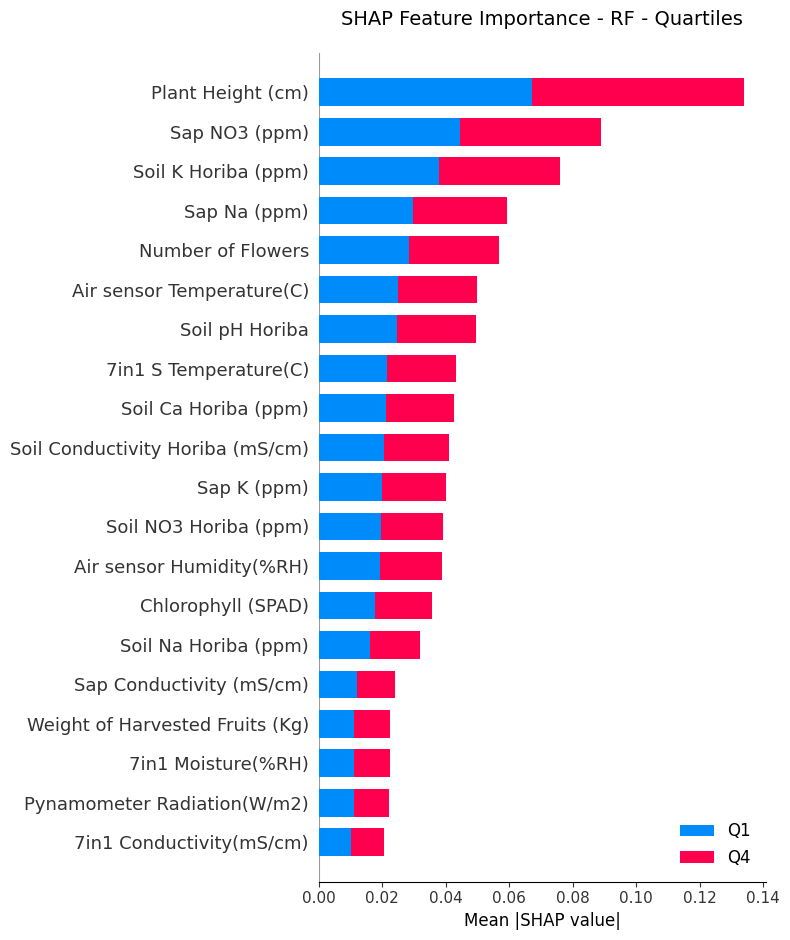

Algoritmo: SVM, Modelo: 2_Quartiles


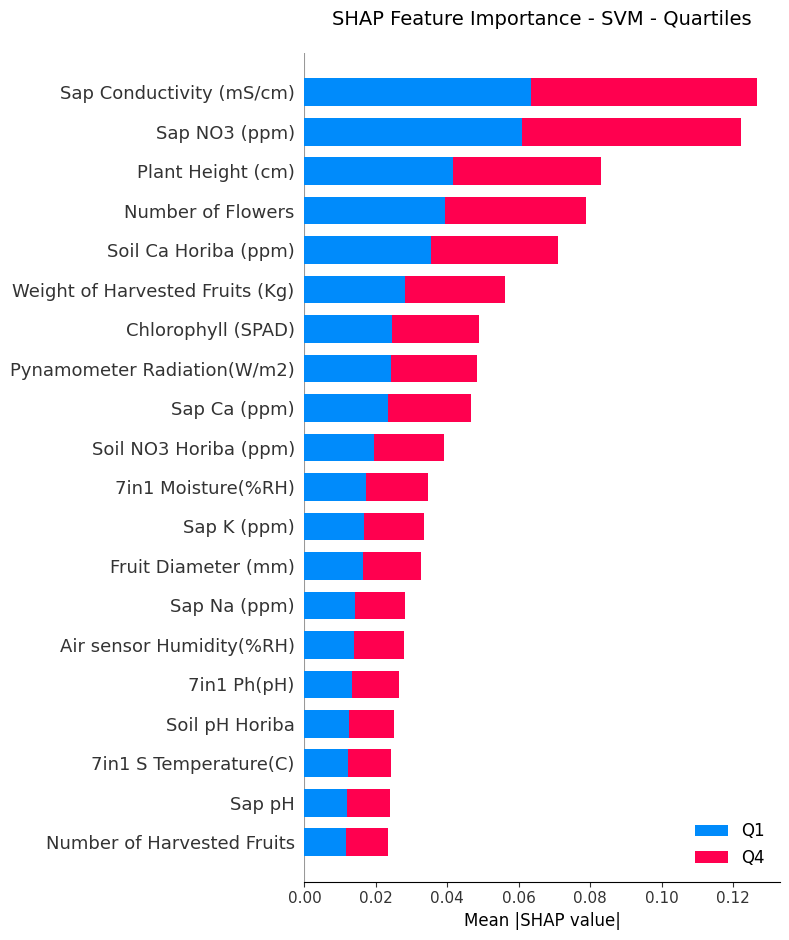

Algoritmo: KNN, Modelo: 2_Quartiles


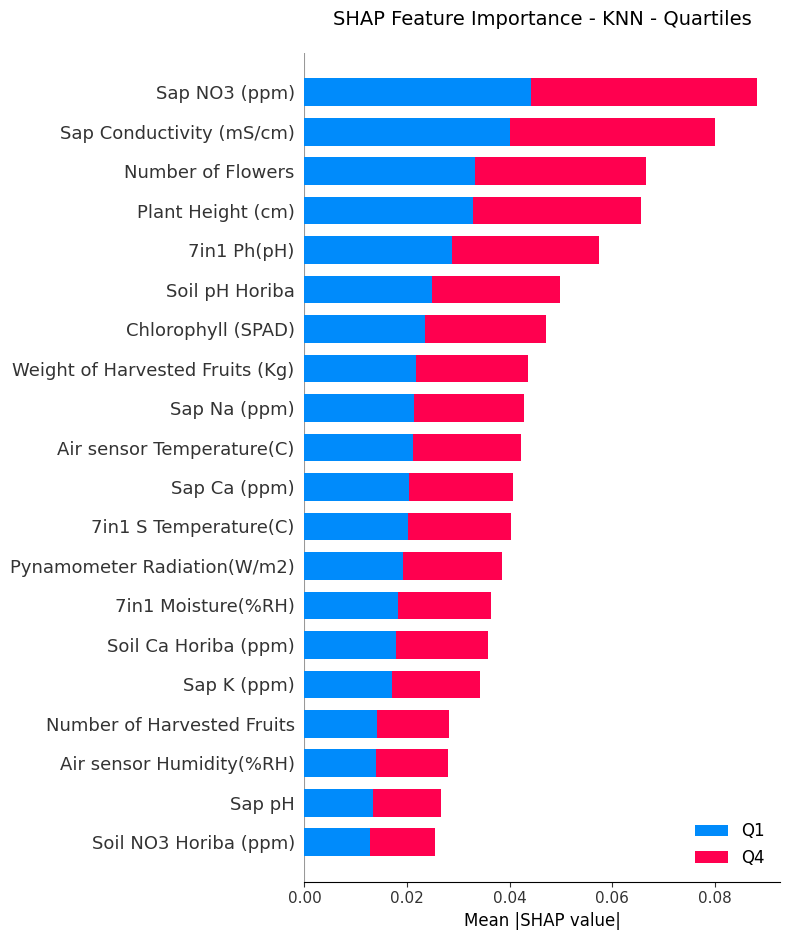

Algoritmo: MLP, Modelo: 2_Quartiles


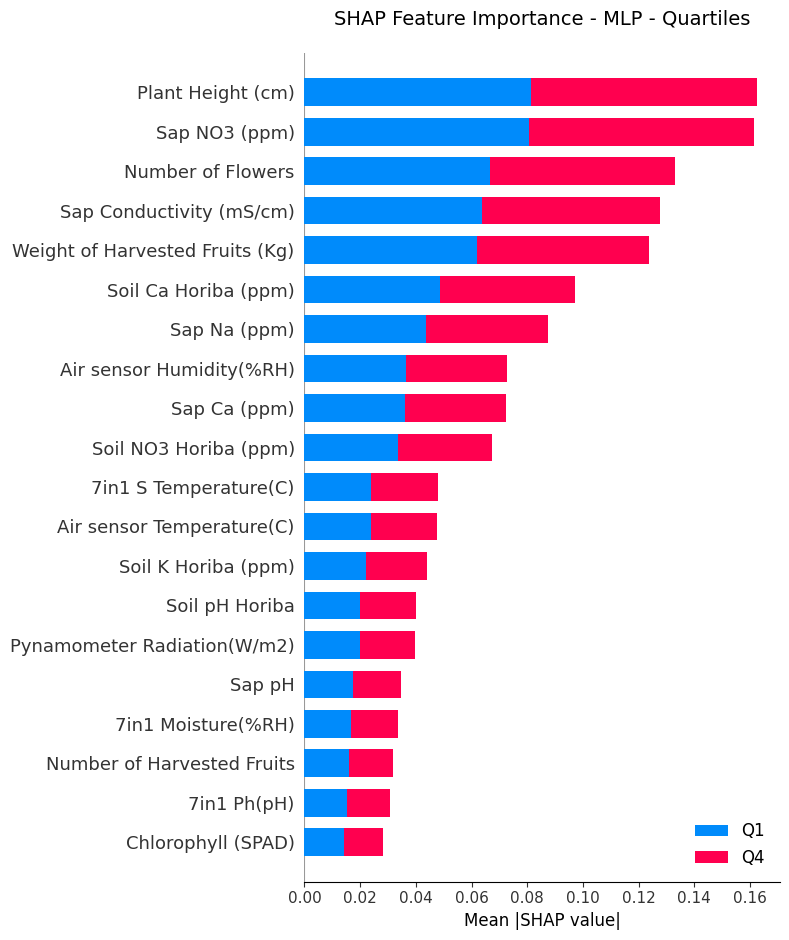

Algoritmo: XGB, Modelo: 2_Quartiles


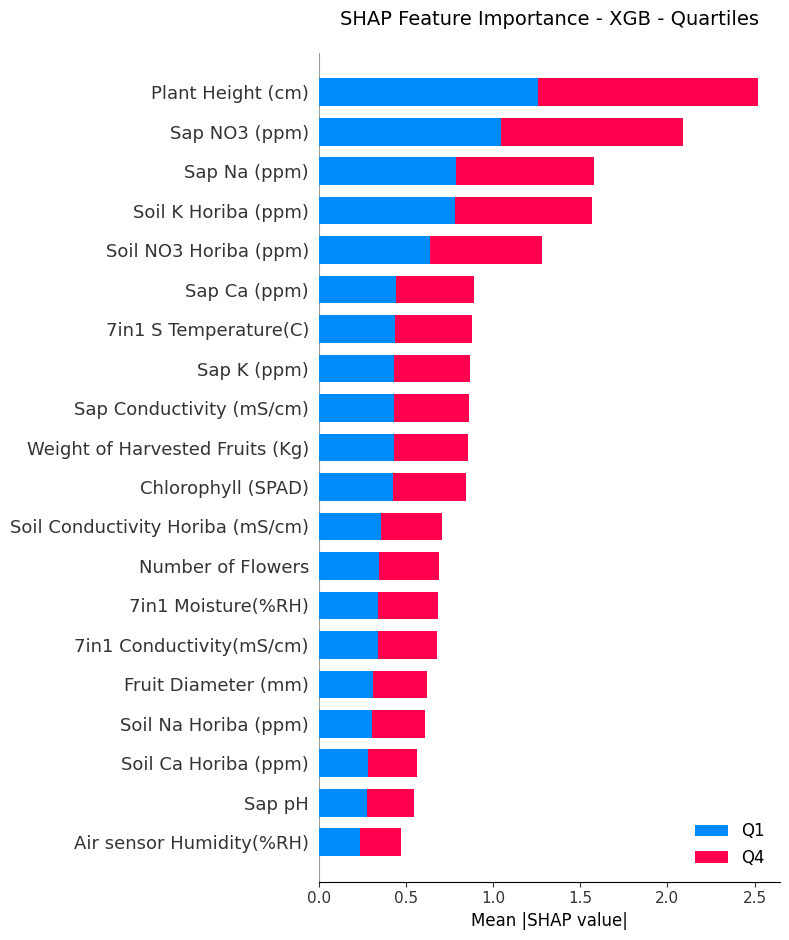

In [50]:
custom_classes = {
    '2_Quartiles': ['Q1', 'Q4']
}
if CFG.cuartiles_train:
    for algorithm, algorithm_results in results.items():
        for model in algorithm_results:
            print(f"Algoritmo: {algorithm}, Modelo: {model['n_clases']}")
            shap_values = model['shap_values']
            X_scaled_df = model['X_scaled_df']
            name_element = "Quartile"
            class_name = custom_classes.get(model['n_clases'], None)
            title = f"SHAP Feature Importance - {algorithm} - Quartiles"
            plot_bar_shap(shap_values, X_scaled_df, 
                        title = title,
                        path=f"{CFG.class_path}{algorithm}/",
                        class_name=class_name,
                        name_element = name_element)

#### 2-9 Classes (Deshabilitado)

In [ ]:
custom_classes = {
    '3_Nitrogen': ['N0', 'N1', 'N2'],
    '3_Phosphorus': ['P0', 'P1', 'P2'],
    '3_Potassium': ['K0', 'K1', 'K2'],
}
if not CFG.individual_train and not CFG.cuartiles_train:
    for algorithm, algorithm_results in results.items():
        for model in algorithm_results:
            print(f"Algoritmo: {algorithm}, Modelo: {model['n_clases']}")
            shap_values = model['shap_values']
            X_scaled_df = model['X_scaled_df']

            name_element = model['n_clases']
            class_name = custom_classes.get(model['n_clases'], None)
            title = f"SHAP Feature Importance - {algorithm} - {model['n_clases']}"
            plot_bar_shap(shap_values, X_scaled_df, 
                        title = title,
                        path=f"{CFG.class_path}{algorithm}/",
                        class_name=class_name,
                        name_element = name_element)

In [ ]:
for algorithm, algorithm_results in results.items():
    for model in algorithm_results:
        print(model['best_params'])